# 10 · Did the site redesign help? (no control group) — interrupted time series (CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** We redesigned the homepage on a known date, for **all** traffic at once — so,
unlike the DiD store rollout (notebook 08), there is **no control group** to compare against. Conversion
is up since the redesign. Is that real lift, or just the normal upward drift the site was already on?
Keep the redesign or roll it back?

### The idea: the past *is* the control group

When everyone is treated at the same moment, the only untreated comparison you have is **the treated unit's
own history**. **Interrupted time series (ITS)** uses it: fit the pre-change series — its **level**, its
**trend** (slope), and its **seasonality** (e.g. weekly cycles) — and then **extrapolate that fitted line
forward** past the change date. That extrapolation is the **counterfactual**: "what conversion *would* have
done if we'd changed nothing." The **gap** between actual conversion and this projection, after the change,
is the estimated effect.

Because it's a forecast, the counterfactual comes with a **credible band that widens the further out we
project** — an honest admission that "what would have happened" is less and less certain over time.

### The assumption and its checks

ITS is the *weakest* of the quasi-experiments because it leans entirely on **no concurrent shock**: nothing
*else* (a price change, a competitor move, a seasonality break) happened at the same date as the redesign,
or ITS will blame the redesign for it. We stress this with a **placebo-in-time** (pretend the change
happened earlier — the fake effect should be ≈ 0), track the **cumulative** impact, and check **residual
autocorrelation** (successive days being correlated, which — if ignored — makes the intervals look tighter
than they should).

> **On real data.** ITS fits any "everyone changed at once on a known date" event: a site redesign, a
> pricing change, a policy launch, a PR crisis. You need a reasonably long, stable **pre-period** and a
> clean intervention date. A famous public example is the effect of anti-smoking laws on cigarette sales.

7-step contract.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import dgp, estimators as est, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 31; REDESIGN = 120; TRUE = 0.03

## 2 · Simulate a ground truth

Daily conversion with a gentle upward trend and weekly seasonality. The redesign lands on **day
120** for everyone and adds a **true +3pp** step. The trend is the confounder (conversion was
already drifting up); the step is the effect.


In [2]:
df, true_lift, redesign_day = dgp.its_redesign(n_days=180, redesign_day=REDESIGN, true_lift=TRUE, seed=SEED)
df = df.set_index("t", drop=False)
print(f"TRUE redesign effect = +{true_lift:.0%} conversion from day {redesign_day}")
df.head()

TRUE redesign effect = +3% conversion from day 120


,t,day,sin7,cos7,conversion
t,,,,,
0,0,0,0.000000,1.000000,0.097628
1,1,1,0.781831,0.623490,0.109552
2,2,2,0.974928,-0.222521,0.113692
3,3,3,0.433884,-0.900969,0.098956
4,4,4,-0.433884,-0.900969,0.100867


## 3 · Identify — extrapolate the pre-trend as the counterfactual

Fit the pre-period series $f(t)$ (level, slope, weekly seasonality) and extrapolate past the
intervention as the no-redesign counterfactual $\hat Y_t(0)$; the effect is $Y_t-\hat Y_t(0)$
afterward. Being Bayesian, the counterfactual is a posterior-predictive band that **widens with
horizon** — honest extrapolation. **Identification assumption (the weakest of the quasi-experimental
set): no concurrent shock** at the redesign date (no competing campaign, price change, or
seasonality break landing at the same time). Best when the change hit everyone at once and the
pre-period is long and stable.


## 4 · Estimate — Bayesian interrupted time series

We fit the pre-period conversion series with a trend term (`t`) and weekly seasonality (`sin7`, `cos7`
Fourier terms — a smooth way to encode the day-of-week cycle), then let the model extrapolate that fit past
the redesign day. The **effect** is the average gap between actual conversion and the extrapolated
no-redesign line over the post-period. The `formula` is literally the shape of the pre-trend we're
projecting forward — get the seasonality wrong and the counterfactual is wrong, so it matters.


In [3]:
result = est.its(df, treatment_time=redesign_day, formula="conversion ~ 1 + t + sin7 + cos7", fast=FAST)
avg_impact = result.post_impact.mean(dim=["treated_units","obs_ind"]).values.ravel()
cum_impact = result.post_impact_cumulative.isel(treated_units=0).values.reshape(-1, (df.t>=redesign_day).sum())
print(f"ITS lift +{avg_impact.mean():.1%} (true +{true_lift:.0%})  ·  90% CI [+{np.quantile(avg_impact,0.05):.1%}, +{np.quantile(avg_impact,0.95):.1%}]")
print(f"ITS convergence: {est.convergence_report(result.idata)["summary"]}")


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


ITS lift +3.0% (true +3%)  ·  90% CI [+2.8%, +3.3%]
ITS convergence: max r-hat 1.000 - min ESS 2918 - divergences 0


## 5 · Validate — counterfactual, cumulative impact, placebo, autocorrelation

Four panels:

1. **Counterfactual** (CausalPy's own plot) — observed vs the extrapolated no-redesign path with its
   widening band, and the impact below.
2. **Cumulative impact** — total extra conversions accrued since launch, with uncertainty.
3. **Placebo-in-time** — pretend the redesign happened *before* it did; the fake effect should be ≈0.
4. **Residual autocorrelation** — daily series are autocorrelated; if the model's residuals still are,
   the uncertainty is understated.


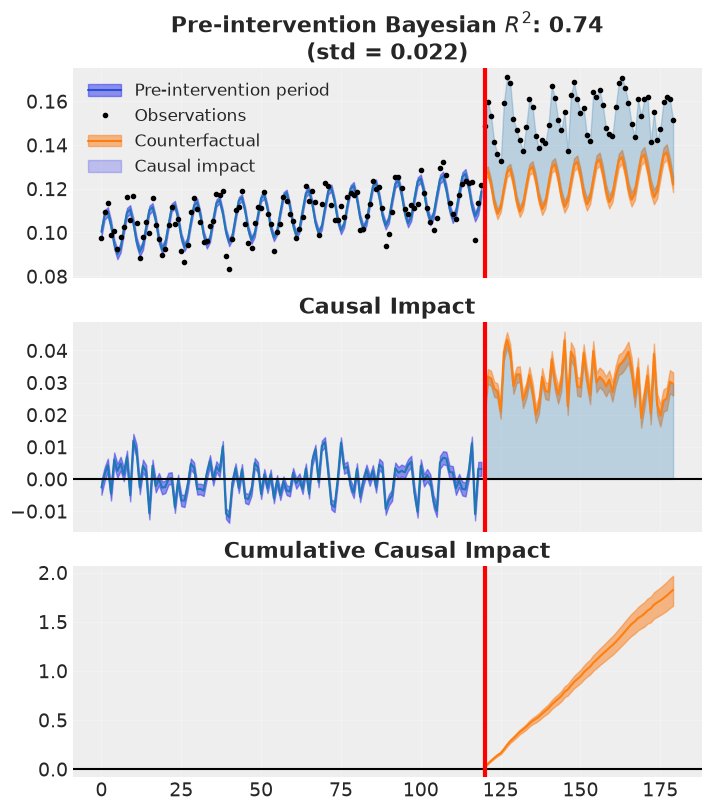

recovered average step +3.0% vs true +3%


In [4]:
fig1, _ = result.plot()
try: fig1.set_size_inches(9, 5)
except Exception: pass
print(f"recovered average step +{avg_impact.mean():.1%} vs true +{true_lift:.0%}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


placebo-in-time +0.0% (≈0, no spurious pre-effect)  ·  residual ACF: 0/10 lags outside the ±2/√n band (lag-1 +0.09) → residuals ≈ white, so the model's intervals are not understated.


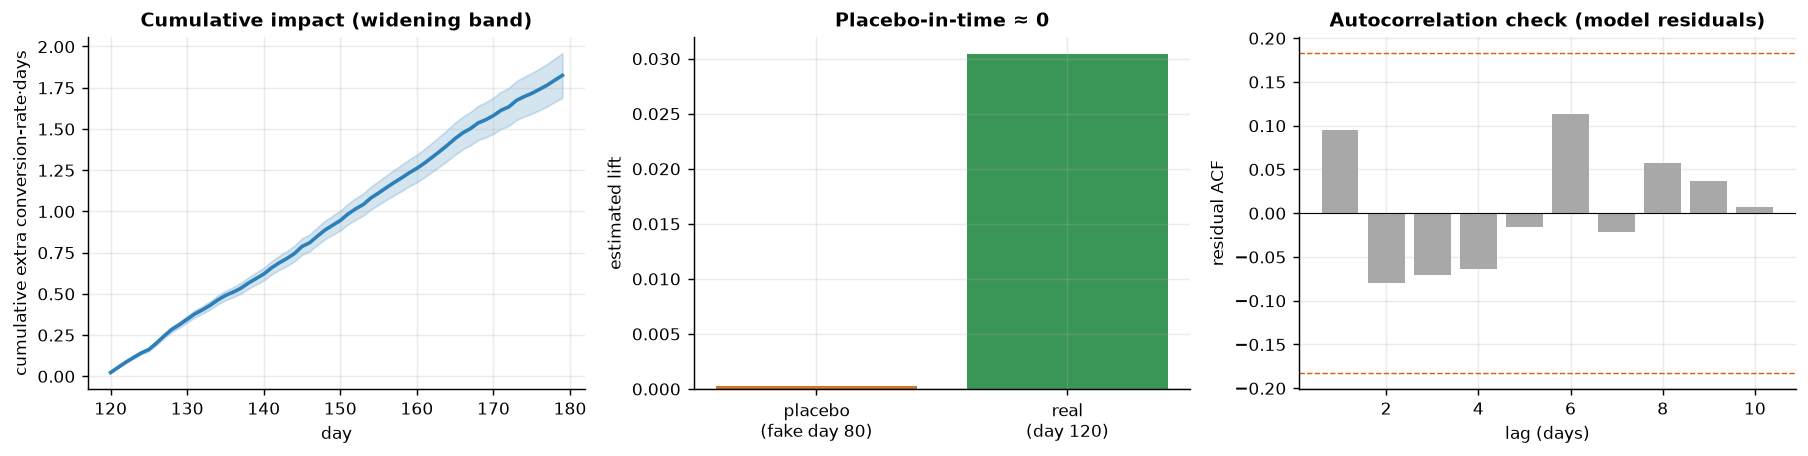

In [5]:
# placebo-in-time: fake redesign at day 80 (before the real one)
FAKE = 80
pre = df[df.t < REDESIGN].copy()
res_p = est.its(pre.set_index("t", drop=False), treatment_time=FAKE, formula="conversion ~ 1 + t + sin7 + cos7", fast=FAST)
placebo = res_p.post_impact.mean(dim=["treated_units","obs_ind"]).values.mean()

# Residual autocorrelation on the pre-period fit — residuals from the SAME model the
# ITS uses (conversion ~ 1 + t + sin7 + cos7), NOT a centred rolling mean. A rolling
# mean removes level/trend but leaves the weekly sin7/cos7 cycle IN, so its "residual"
# ACF shows a big spurious lag-7 spike for seasonality the model already fits. Only the
# model residual is the honest check on whether uncertainty is understated.
Dpre = np.column_stack([np.ones(len(pre)), pre.t.values, pre.sin7.values, pre.cos7.values])
beta_pre, *_ = np.linalg.lstsq(Dpre, pre.conversion.values, rcond=None)
resid = pre.conversion.values - Dpre @ beta_pre
def acf(x, k): x=x-x.mean(); return np.correlate(x[:-k], x[k:])[0]/np.correlate(x,x)[0]
lags = range(1, 11); acfs = [acf(resid, k) for k in lags]
band = 2/np.sqrt(len(resid))

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
post_days = np.arange(REDESIGN, len(df))
ax[0].plot(post_days, cum_impact.mean(0), color=plots.BLUE, lw=2)
ax[0].fill_between(post_days, np.quantile(cum_impact,0.05,0), np.quantile(cum_impact,0.95,0), color=plots.BLUE, alpha=0.2)
ax[0].set_xlabel("day"); ax[0].set_ylabel("cumulative extra conversion-rate·days"); ax[0].set_title("Cumulative impact (widening band)")
ax[1].axhline(0, color="k", lw=0.6); ax[1].bar(["placebo\n(fake day 80)","real\n(day 120)"], [placebo, avg_impact.mean()],
    color=[plots.ORANGE, plots.GREEN], alpha=0.9); ax[1].set_ylabel("estimated lift"); ax[1].set_title("Placebo-in-time ≈ 0")
ax[2].bar(list(lags), acfs, color=plots.GREY, alpha=0.85); ax[2].axhline(0, color="k", lw=0.6)
ax[2].axhline(band, color=plots.ORANGE, ls="--", lw=0.8); ax[2].axhline(-band, color=plots.ORANGE, ls="--", lw=0.8)
ax[2].set_xlabel("lag (days)"); ax[2].set_ylabel("residual ACF"); ax[2].set_title("Autocorrelation check (model residuals)")
fig.tight_layout()
n_out = int(np.sum(np.abs(acfs) > band))
print(f"placebo-in-time +{placebo:.1%} (≈0, no spurious pre-effect)  ·  residual ACF: {n_out}/10 lags outside the "
      f"±2/√n band (lag-1 {acfs[0]:+.2f}) → residuals ≈ white, so the model's intervals are not understated.")
plt.show()

**How to read this.** *Left* — the **cumulative** impact (total extra conversions accrued since the
redesign) climbs steadily, and its band **fans out** the further we project — the honest statement that
long-horizon totals are less certain. *Middle* — the key falsification: we re-ran the whole method with a
**fake** redesign date back in the pre-period; the fake effect is ≈ 0, so the method isn't inventing lift
where none exists. If this bar had been large, our real estimate would be suspect. *Right* — the residual
autocorrelation (ACF) of the **model's own residuals** (after fitting the same trend + weekly-seasonality
terms the ITS uses): essentially every bar sits inside the ±2/√n band, so successive days are effectively
uncorrelated and the model's intervals are not understated. (Computing this ACF on a crude rolling-mean
"residual" instead would leave the weekly cycle in and fake an alarming lag-7 spike — a self-inflicted false
alarm we avoid by residualising against the actual model.)

## 6 · Decide, in euros — keep or roll back?

A redesign lift is rarely permanent — **novelty fades**. Projecting the measured 60-day lift *flat* across a
whole year (a naive `lift × visitors × value × 365`) contradicts this notebook's own "uncertainty grows with
horizon" message. So we decide against an explicit **redesign cost** and sweep the **persistence**: the effect
decays with a novelty half-life, and we discount future days accordingly (effective days
$=\sum_t 0.5^{\,t/\text{half-life}}$). For each persistence scenario we report the annual value and
**P(annual value > cost)**. The 0.9 go/no-go bar is the cookbook's convention — act only when the posterior is
at least 90% sure the value clears the cost.

In [6]:
DAILY_VISITORS, VALUE, HORIZON = 8000, 40.0, 365
REDESIGN_COST = 600_000.0             # amortized build + one year of maintenance (a stated assumption)
daily_value = avg_impact * DAILY_VISITORS * VALUE     # € per day at the full (undecayed) lift, per draw
p_pos = (avg_impact > 0).mean()

# Persistence sweep: novelty-driven lift decays. Effective days = sum_t 0.5**(t / half_life),
# so a permanent effect keeps all 365 days while a fast-fading one keeps far fewer.
def effective_days(h, H=HORIZON):
    if np.isinf(h): return float(H)
    return float(np.sum(0.5 ** (np.arange(H) / h)))
scenarios = [(np.inf, "no decay"), (180.0, "6-month"), (90.0, "3-month"), (30.0, "1-month")]

print(f"Undecayed lift: {avg_impact.mean()*DAILY_VISITORS:,.0f} extra conversions/day  ·  €{daily_value.mean():,.0f}/day")
print(f"Assumed amortized redesign cost: €{REDESIGN_COST:,.0f}/year\n")
print(f"{'novelty half-life':>18} | {'eff. days':>9} | {'annual value (mean)':>19} | {'P(value>cost)':>13} | verdict")
for h, lab in scenarios:
    ed = effective_days(h); annual_h = daily_value * ed; p_cost = (annual_h > REDESIGN_COST).mean()
    verdict = "KEEP" if p_cost > 0.9 else ("roll back / renew" if p_cost < 0.5 else "renew & re-test")
    print(f"{lab:>18} | {ed:9.0f} | €{annual_h.mean():>17,.0f} | {p_cost:>13.2f} | {verdict}")

be_lift = REDESIGN_COST / (DAILY_VISITORS * VALUE * HORIZON)
print(f"\nBreak-even lift (no decay): {be_lift*100:.2f}pp of conversions covers the €{REDESIGN_COST:,.0f} cost; "
      f"we estimate {avg_impact.mean()*100:.1f}pp.")
print(f"P(redesign helped at all) {'>0.99' if p_pos > 0.99 else f'{p_pos:.2f}'} ({avg_impact.size:,} draws) → "
      f"KEEP under any realistic persistence; only a harsh 1-month novelty half-life turns it into a re-test.")

Undecayed lift: 243 extra conversions/day  ·  €9,731/day
Assumed amortized redesign cost: €600,000/year

 novelty half-life | eff. days | annual value (mean) | P(value>cost) | verdict
          no decay |       365 | €        3,551,767 |          1.00 | KEEP
           6-month |       196 | €        1,910,943 |          1.00 | KEEP
           3-month |       123 | €        1,192,075 |          1.00 | KEEP
           1-month |        44 | €          425,952 |          0.00 | roll back / renew

Break-even lift (no decay): 0.51pp of conversions covers the €600,000 cost; we estimate 3.0pp.
P(redesign helped at all) >0.99 (4,000 draws) → KEEP under any realistic persistence; only a harsh 1-month novelty half-life turns it into a re-test.


## 7 · Caveats

- **The no-concurrent-shock assumption is the weak link.** A pricing change or competitor move at the
  redesign date gets attributed to the redesign. Vet the calendar around the intervention.
- **Uncertainty grows with horizon** — the band (and cumulative-impact band) widens; long-horizon claims
  are genuinely less certain.
- **A control group beats extrapolation.** If even a small hold-out or comparable untreated series
  exists, DiD (nb 08) or synthetic control (nb 07) are stronger. ITS is the last resort when *everyone*
  was treated.
- **Autocorrelation.** If residuals are autocorrelated (checked above), a naive model understates
  uncertainty; prefer trend/seasonality structure or explicit AR terms.
